In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

In [4]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['svg.fonttype'] = 'none'

## load layouts for multiple experiments

In [3]:
Experiment1Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_PTEFB/250915_mACmChPOLR2A_PTEFB/METADATA/250915_mACmChPOLR2A_PTEFB.csv")
Experiment2Layout = pd.read_csv("/Users/alexandergillis/Desktop/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACmChPOLR2A_PTEFB/251007_mACmChPOLR2A_PTEFB/METADATA/251007_mACmChPOLR2A_PTEFB.csv")

## load quantification files and assemble into dataframes

In [5]:
Experiment1_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250915_mACmChPOLR2A_PTEFB/20250918_190817_921/QUANTIFICATION/")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))

Experiment2_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251007_mACmChPOLR2A_PTEFB/20251013_174253_942/QUANTIFICATION")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))

len(Experiment1_Quantification_Files), len(Experiment2_Quantification_Files)

(929, 916)

In [6]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment1_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment1_PerCell['fov'] = fovs

Experiment1_Intensities = pd.DataFrame({
    "WELL" : Experiment1_PerCell['well'],
    "IF_647_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment1_PerCell['Nuclei_area']
})

100%|█████████████████████████████████████████| 929/929 [00:10<00:00, 86.29it/s]


In [7]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_PerCell['file'].tolist()


wellnames = [f[4:7] for f in files]
Experiment2_PerCell['well'] = wellnames

fovs = [f[40:44] for f in files]
Experiment2_PerCell['fov'] = fovs

Experiment2_Intensities = pd.DataFrame({
    "WELL" : Experiment2_PerCell['well'],
    "IF_647_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_647'],
    "RFP_561_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_561'],
    "GFP_488_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_PerCell['Nuclei_intensity_mean_405'],
    "NucleusArea" : Experiment2_PerCell['Nuclei_area']
})

100%|████████████████████████████████████████| 916/916 [00:04<00:00, 210.92it/s]


In [8]:
CountsByWell1 = Experiment1_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1 = Experiment1_Intensities.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.merge(CountsByWell1, how = 'left')
IntensitiesByWell_Experiment1['EXPERIMENT'] = '250915_mACmChPOLR2A_PTEFB'

CountsByWell2 = Experiment2_Intensities.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2 = Experiment2_Intensities.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.merge(CountsByWell2, how = 'left')
IntensitiesByWell_Experiment2['EXPERIMENT'] = '251007_mACmChPOLR2A_PTEFB'

## examine raw data by experiment

In [9]:
IntensitiesByWell_Experiment1['DRUG_AND_TIME'] = IntensitiesByWell_Experiment1['DRUG'] + "_" + IntensitiesByWell_Experiment1['TIME_MINUTES'].astype(str)
IntensitiesByWell_Experiment2['DRUG_AND_TIME'] = IntensitiesByWell_Experiment2['DRUG'] + "_" + IntensitiesByWell_Experiment2['TIME_MINUTES'].astype(str)

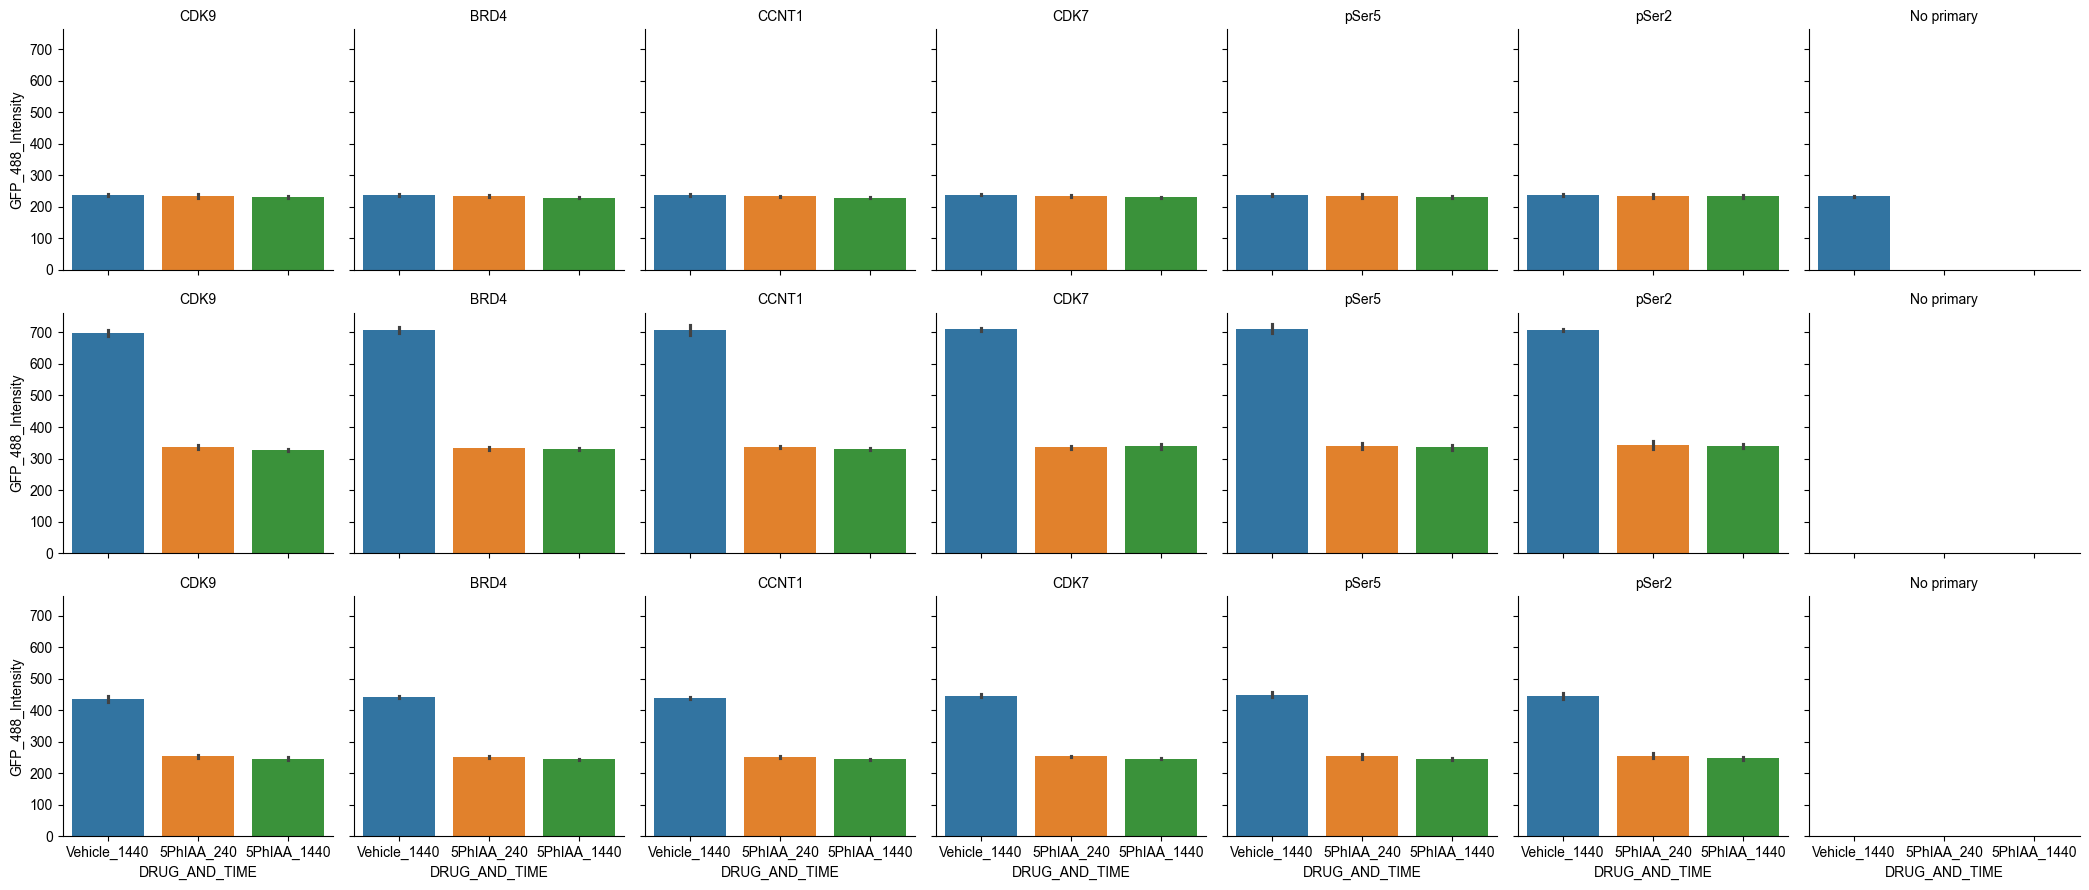

In [10]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1,
                  col = 'PRIMARY',
                  row = 'CELL',
                 aspect = 1)

g.map_dataframe(sns.barplot,
                x = 'DRUG_AND_TIME',
                hue = 'DRUG_AND_TIME', dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'GFP_488_Intensity')

g.set_titles(template="{col_name}")

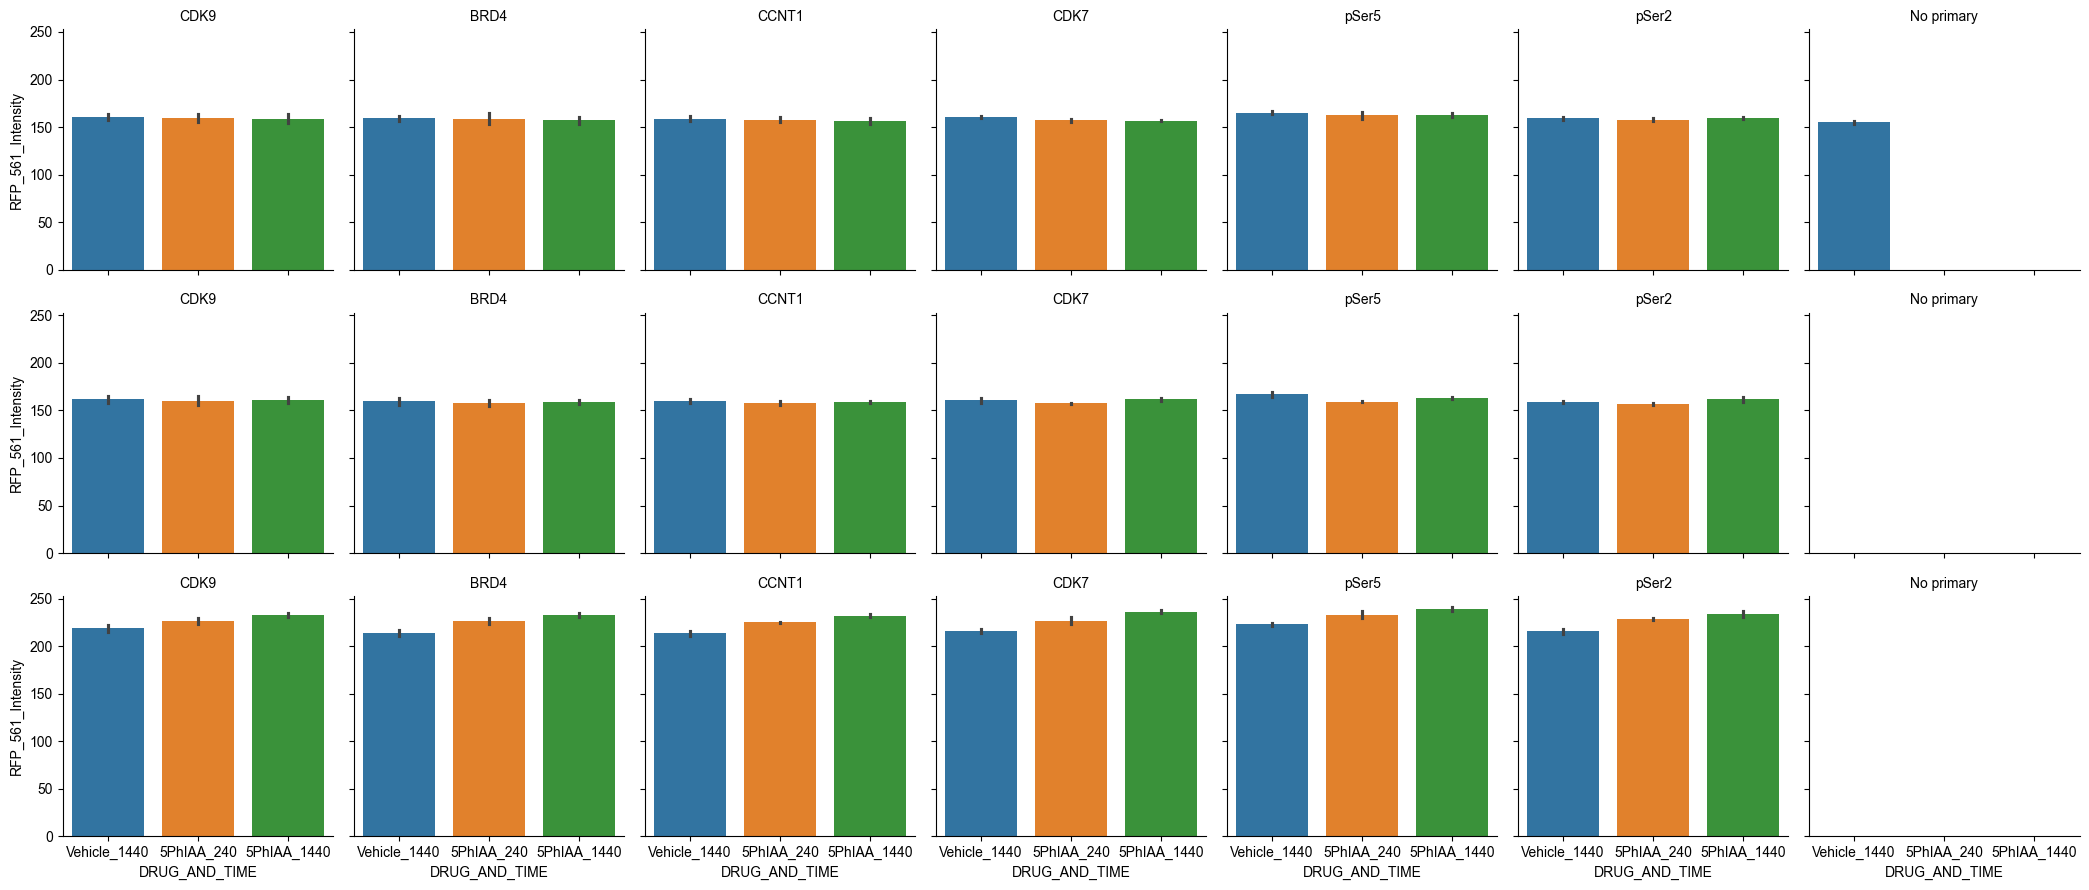

In [11]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1,
                  col = 'PRIMARY',
                  row = 'CELL',
                 aspect = 1)

g.map_dataframe(sns.barplot,
                x = 'DRUG_AND_TIME',
                hue = 'DRUG_AND_TIME', dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'RFP_561_Intensity')

g.set_titles(template="{col_name}")

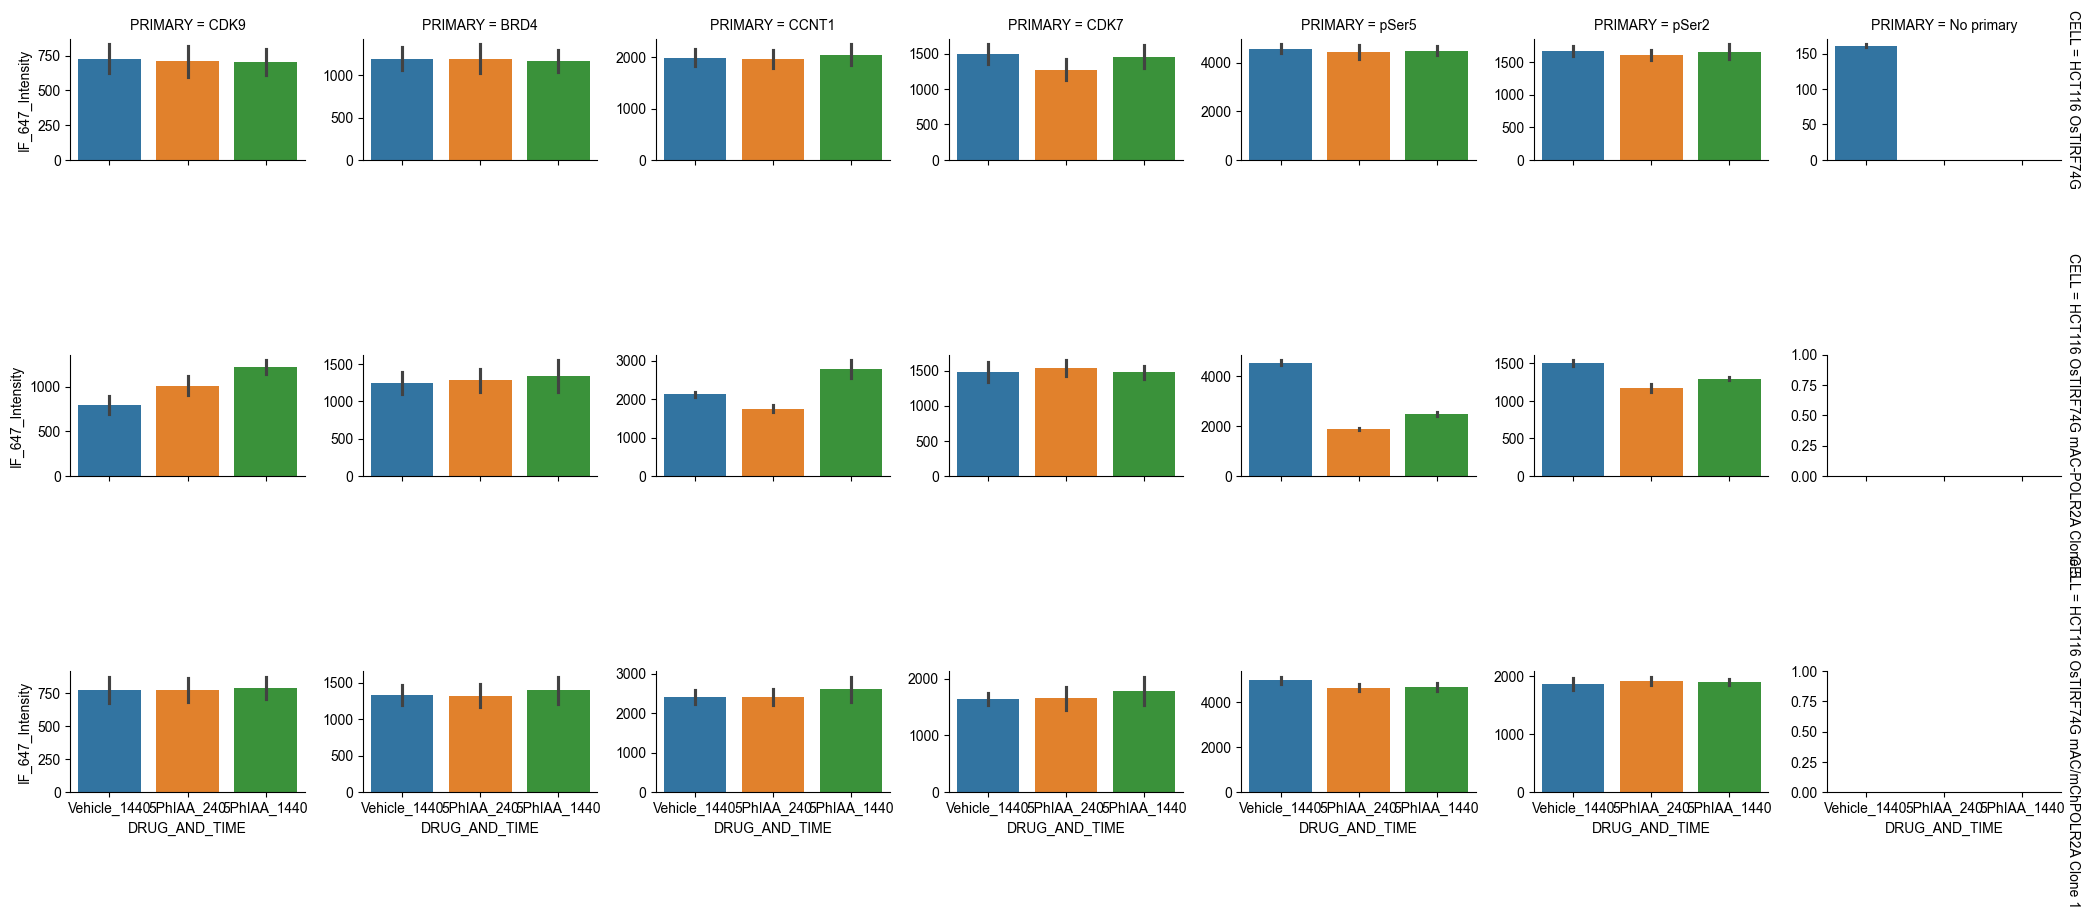

In [12]:
g = sns.FacetGrid(IntensitiesByWell_Experiment1,
                  col = 'PRIMARY',
                  row = 'CELL',
                 aspect = 1,
                  sharey = False,
                  margin_titles = True)

g.map_dataframe(sns.barplot,
                x = 'DRUG_AND_TIME',
                hue = 'DRUG_AND_TIME', dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'IF_647_Intensity')

g.set_titles(template="{col_name}")

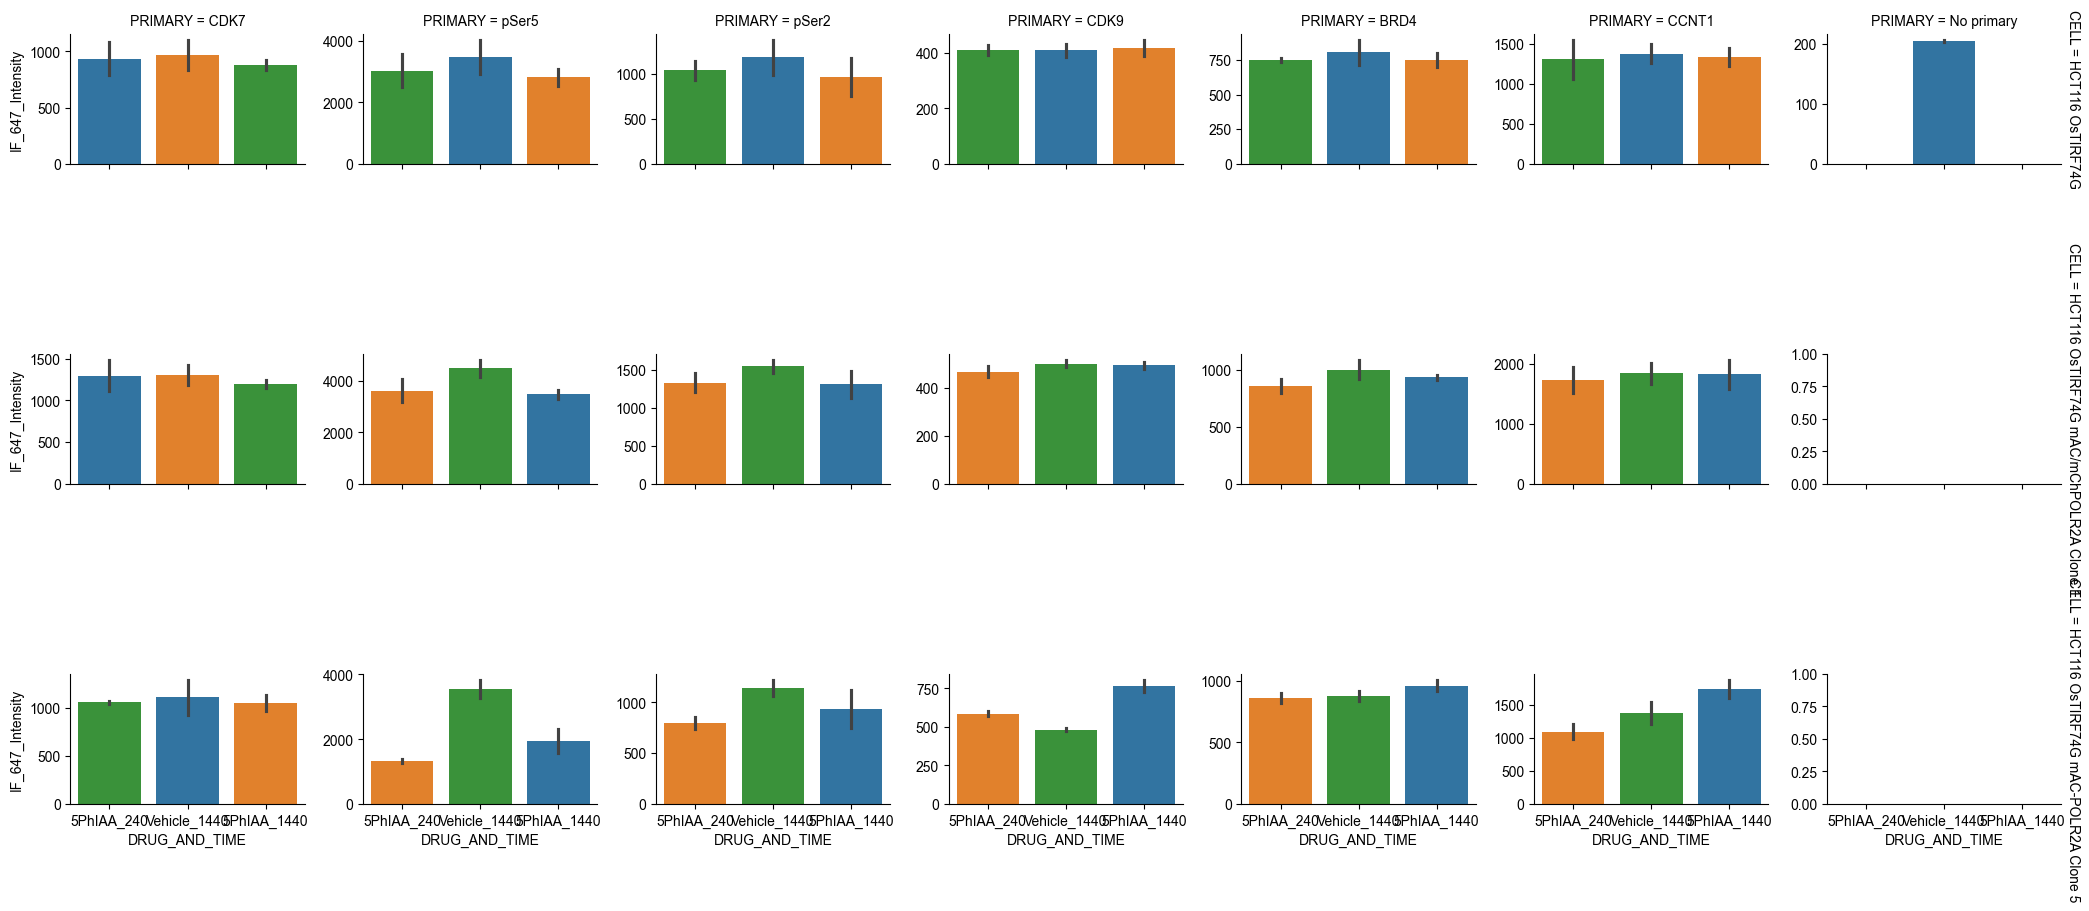

In [13]:
g = sns.FacetGrid(IntensitiesByWell_Experiment2,
                  col = 'PRIMARY',
                  row = 'CELL',
                 aspect = 1,
                  sharey = False,
                  margin_titles = True)

g.map_dataframe(sns.barplot,
                x = 'DRUG_AND_TIME',
                hue = 'DRUG_AND_TIME', dodge = False, palette = 'tab10',
                errorbar = 'sd',
                y = 'IF_647_Intensity')

g.set_titles(template="{col_name}")

## background subtract and normalise within each experiment for mACPOLR2A cells

In [14]:
ZeroVal_E1 = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary"')['IF_647_Intensity'].mean()
ZeroVal_E2 = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary"')['IF_647_Intensity'].mean()

IntensitiesByWell_Experiment1['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment1['IF_647_Intensity'] - ZeroVal_E1
IntensitiesByWell_Experiment2['IF_647_Intensity_BGS'] = IntensitiesByWell_Experiment2['IF_647_Intensity'] - ZeroVal_E2

In [15]:
IntensitiesByWell_Experiment1_mACPOLR2A = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"')
IntensitiesByWell_Experiment2_mACPOLR2A = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"')

In [16]:
frames = []

for p in IntensitiesByWell_Experiment1_mACPOLR2A.query('PRIMARY != "No primary"').PRIMARY.unique():
    
    p_frame = IntensitiesByWell_Experiment1_mACPOLR2A[IntensitiesByWell_Experiment1_mACPOLR2A['PRIMARY'] == p]
    
    Hundred_Val = p_frame.query('DRUG == "Vehicle"').IF_647_Intensity_BGS.mean()

    p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)

    frames.append(p_frame)

NormalisedIntensitiesByWell_Experiment1_mACPOLR2A = pd.concat(frames)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/777977615.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/777977615.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/777977615.py:9: SettingWithCopy

In [17]:
frames = []

for p in IntensitiesByWell_Experiment2_mACPOLR2A.query('PRIMARY != "No primary"').PRIMARY.unique():
    
    p_frame = IntensitiesByWell_Experiment2_mACPOLR2A[IntensitiesByWell_Experiment2_mACPOLR2A['PRIMARY'] == p]
    
    Hundred_Val = p_frame.query('DRUG == "Vehicle"').IF_647_Intensity_BGS.mean()

    p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)

    frames.append(p_frame)

NormalisedIntensitiesByWell_Experiment2_mACPOLR2A = pd.concat(frames)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/2890715874.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/2890715874.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/2890715874.py:9: SettingWithC

In [18]:
NormalisedIntensitiesByWell_mACPOLR2A = pd.concat([NormalisedIntensitiesByWell_Experiment1_mACPOLR2A, NormalisedIntensitiesByWell_Experiment2_mACPOLR2A])
NormalisedIntensitiesByWell_mACPOLR2A = NormalisedIntensitiesByWell_mACPOLR2A.query('DRUG != "No addition"')

## background subtract and normalise within each experiment for mAC-/mCherry-POLR2A cells

In [19]:
IntensitiesByWell_Experiment1_mACmCh = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC/mChPOLR2A Clone 1"')
IntensitiesByWell_Experiment2_mACmCh = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC/mChPOLR2A Clone 1"')

In [20]:
frames = []

for p in IntensitiesByWell_Experiment1_mACmCh.query('PRIMARY != "No primary"').PRIMARY.unique():
    
    p_frame = IntensitiesByWell_Experiment1_mACmCh[IntensitiesByWell_Experiment1_mACmCh['PRIMARY'] == p]
    
    Hundred_Val = p_frame.query('DRUG == "Vehicle"').IF_647_Intensity_BGS.mean()

    p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)

    frames.append(p_frame)

NormalisedIntensitiesByWell_Experiment1_mACmCh = pd.concat(frames)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/1861864341.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/1861864341.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/1861864341.py:9: SettingWithC

In [21]:
frames = []

for p in IntensitiesByWell_Experiment2_mACmCh.query('PRIMARY != "No primary"').PRIMARY.unique():
    
    p_frame = IntensitiesByWell_Experiment2_mACmCh[IntensitiesByWell_Experiment2_mACmCh['PRIMARY'] == p]
    
    Hundred_Val = p_frame.query('DRUG == "Vehicle"').IF_647_Intensity_BGS.mean()

    p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)

    frames.append(p_frame)

NormalisedIntensitiesByWell_Experiment2_mACmCh = pd.concat(frames)

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/2247801176.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/2247801176.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p_frame['IF_647_Intensity_FC'] = (p_frame['IF_647_Intensity_BGS'] / Hundred_Val)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_91885/2247801176.py:9: SettingWithC

In [22]:
NormalisedIntensitiesByWell_mACmCh = pd.concat([NormalisedIntensitiesByWell_Experiment1_mACmCh, NormalisedIntensitiesByWell_Experiment2_mACmCh])
NormalisedIntensitiesByWell_mACmCh = NormalisedIntensitiesByWell_mACmCh.query('DRUG != "No addition"')

# Plots for manuscript

In [23]:
NormalisedIntensitiesByWell_mACPOLR2A.PRIMARY.unique()

array(['CDK9', 'BRD4', 'CCNT1', 'CDK7', 'pSer5', 'pSer2'], dtype=object)

In [24]:
NormalisedIntensitiesByWell_mACPOLR2A['DRUG_AND_TIME_LABEL'] = NormalisedIntensitiesByWell_mACPOLR2A.DRUG_AND_TIME.map(dict(zip(['Vehicle_1440', '5PhIAA_240', '5PhIAA_1440'], ['Vehicle', '4 hrs', '24 hrs'])))
NormalisedIntensitiesByWell_mACmCh['DRUG_AND_TIME_LABEL'] = NormalisedIntensitiesByWell_mACmCh.DRUG_AND_TIME.map(dict(zip(['Vehicle_1440', '5PhIAA_240', '5PhIAA_1440'], ['Vehicle', '4 hrs', '24 hrs'])))

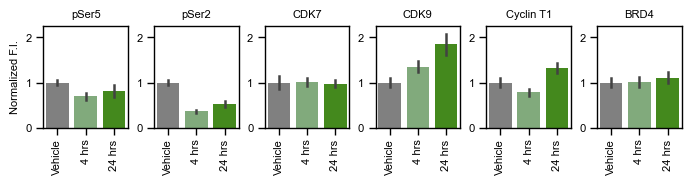

In [42]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 6, figsize = (6.8, 1.7), layout = 'constrained')

pal = sns.color_palette(['grey', 'xkcd:faded green', 'xkcd:grass green'])


a[0].set_title('pSer5', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACPOLR2A.query('PRIMARY == "pSer5"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[1])
#g.get_legend().remove()

a[1].set_title('pSer2', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACPOLR2A.query('PRIMARY == "pSer2"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[0])
#g.get_legend().remove()


a[2].set_title('CDK7', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACPOLR2A.query('PRIMARY == "CDK7"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[2])
#g.get_legend().remove()

a[3].set_title('CDK9', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACPOLR2A.query('PRIMARY == "CDK9"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[3])
#g.get_legend().remove()

a[4].set_title('Cyclin T1', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACPOLR2A.query('PRIMARY == "CCNT1"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[4])
#g.get_legend().remove()

a[5].set_title('BRD4', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACPOLR2A.query('PRIMARY == "BRD4"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[5])
#g.get_legend().remove()

for i in range(6):
    a[i].set_box_aspect(1.2)
    a[i].set_xlabel('')
    a[i].set_ylim(0,2.25)
    a[i].set_ylabel('')
    a[i].tick_params(axis='x', labelsize=8, rotation = 90)
    a[i].tick_params(axis='y', labelsize=8)
a[0].set_ylabel('Normalized F.I.', fontsize = 8)

plt.savefig('mACPOLR2A_4hr_24hr_pSer2_pSer5_CDK7_CDK_CCNT1_BRD4.svg')

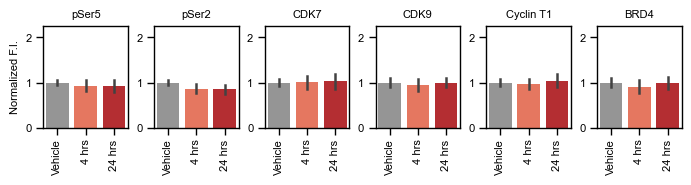

In [43]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 6, figsize = (6.8, 1.7), layout = 'constrained')

pal2 = sns.color_palette([
    sns.color_palette('Greys',n_colors = 3)[1],
    sns.color_palette('Reds',n_colors = 3)[1],
    sns.color_palette('Reds',n_colors = 3)[2]])



a[0].set_title('pSer5', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACmCh.query('PRIMARY == "pSer5"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal2, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[1])

a[1].set_title('pSer2', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACmCh.query('PRIMARY == "pSer2"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal2, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[0])


a[2].set_title('CDK7', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACmCh.query('PRIMARY == "CDK7"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal2, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[2])


a[3].set_title('CDK9', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACmCh.query('PRIMARY == "CDK9"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal2, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[3])


a[4].set_title('Cyclin T1', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACmCh.query('PRIMARY == "CCNT1"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal2, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[4])

a[5].set_title('BRD4', fontsize = 8)
g = sns.barplot(NormalisedIntensitiesByWell_mACmCh.query('PRIMARY == "BRD4"'),
            x = 'DRUG_AND_TIME_LABEL', 
            hue = 'DRUG_AND_TIME_LABEL', palette = pal2, dodge = False,
            y = 'IF_647_Intensity_FC',
            errorbar = 'sd',
            ax = a[5])

for i in range(6):
    a[i].set_box_aspect(1.2)
    a[i].set_xlabel('')
    a[i].set_ylim(0,2.25)
    a[i].set_ylabel('', fontsize = 8)
    a[i].tick_params(axis='x', labelsize=8, rotation = 90)
    a[i].tick_params(axis='y', labelsize=8)
a[0].set_ylabel('Normalized F.I.', fontsize = 8)

plt.savefig('mACmChPOLR2A_4hr_24hr_pSer2_pSer5_CDK7_CDK_CCNT1_BRD4.svg')